In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, classification_report
from tqdm import tqdm
import json
from typing import Optional, Tuple
import os

# Set device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Set your tensor directory
TENSOR_DIR = 'tensors_rep/'


X_train = np.load(TENSOR_DIR + 'X_train.npy')
X_val = np.load(TENSOR_DIR + 'X_val.npy')
X_test = np.load(TENSOR_DIR + 'X_test.npy')
y_train = np.load(TENSOR_DIR + 'y_train.npy')
y_val = np.load(TENSOR_DIR + 'y_val.npy')
y_test = np.load(TENSOR_DIR + 'y_test.npy')
mask_train = np.load(TENSOR_DIR + 'mask_train.npy')
mask_val = np.load(TENSOR_DIR + 'mask_val.npy')
mask_test = np.load(TENSOR_DIR + 'mask_test.npy')

Device: cuda


In [2]:
from model import build_training_components

model, criterion, optimizer = build_training_components(X_train, y_train, DEVICE)

In [6]:
import shap
import matplotlib.pyplot as plt
import pandas as pd


model.load_state_dict(torch.load('coi_gpt.pt', map_location='cpu'))
model.eval()

ChainOfInfluence(
  (input_proj): Linear(in_features=30, out_features=64, bias=True)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (temporal_lstm): LSTM(64, 32, batch_first=True, bidirectional=True)
  (feature_lstm): LSTM(64, 32, batch_first=True, bidirectional=True)
  (temporal_attn_proj): Linear(in_features=64, out_features=1, bias=True)
  (feature_attn_proj): Linear(in_features=64, out_features=64, bias=True)
  (transformer_layers): ModuleList(
    (0-1): 2 x DyTTransformerEncoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (linear1): Linear(in_features=64, out_features=256, bias=True)
      (linear2): Linear(in_features=256, out_features=64, bias=True)
      (norm1): DyT()
      (norm2): DyT()
      (dropout): Dropout(p=0.2, inplace=False)
      (dropout1): Dropout(p=0.2, inplace=False)
      (dropout2): Dropout(p=0.2, inplace=False)
 

In [7]:
class CoIShAPWrapper:
    def __init__(self, model, mask_full, device, T, batch_size=32):
        self.model      = model
        self.mask_full  = mask_full   # real mask (N, T)
        self.device     = device
        self.T          = T
        self.batch_size = batch_size
    
    def __call__(self, X_flat):
        n  = X_flat.shape[0]
        Fv = X_flat.shape[1] // self.T
        X  = X_flat.reshape(n, self.T, Fv)
        
        all_probs = []
        for i in range(0, n, self.batch_size):
            batch_X = X[i:i+self.batch_size]
            b       = batch_X.shape[0]
            
            # use real masks for this batch, cycling if needed
            mask_idx = np.arange(i, i+b) % len(self.mask_full)
            batch_m  = self.mask_full[mask_idx]
            
            X_t = torch.FloatTensor(batch_X).to(self.device)
            m_t = torch.BoolTensor(batch_m).to(self.device)
            
            with torch.no_grad():
                logits, _ = self.model(X_t, m_t)
                probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
        
        return np.array(all_probs)

In [9]:
np.random.seed(42)
dead_idx     = np.where(y_test == 1)[0]
survived_idx = np.where(y_test == 0)[0]

# background: mix of survived and died
bg_idx = np.concatenate([
    np.random.choice(survived_idx, 20, replace=False),
    np.random.choice(dead_idx,     10, replace=False)
])
X_bg_flat = X_test[bg_idx].reshape(len(bg_idx), -1)

# explain on deceased only
explain_idx    = np.random.choice(dead_idx, 50, replace=False)
X_explain_flat = X_test[explain_idx].reshape(len(explain_idx), -1)

print(f"Background: {len(bg_idx)}, Explain: {len(explain_idx)}")

Background: 30, Explain: 50


In [11]:
T = 48
wrapper   = CoIShAPWrapper(model, mask_test, DEVICE, T, batch_size=16)
explainer = shap.KernelExplainer(wrapper, X_bg_flat)

print("Computing SHAP values...")
shap_values = explainer.shap_values(X_explain_flat, nsamples=200)
print(f"SHAP values shape: {shap_values.shape}")


Computing SHAP values...


100%|██████████| 50/50 [00:25<00:00,  1.96it/s]

SHAP values shape: (50, 1440)


In [14]:
with open(TENSOR_DIR + 'metadata.json', 'r') as f:
    metadata = json.load(f)

N, T, F = X_test.shape
original_features = metadata['original_features']   # 15 features
gap_features = metadata['gap_features']             # 15 features
feature_names = metadata['all_features']      

Top features: ['sodium', 'creatinine', 'wbc', 'dbp', 'heart_rate']
Bottom features: ['time_since_last_age', 'time_since_last_gender']

SHAP FEATURE IMPORTANCE (deceased patients)
                         Feature  Mean SHAP  Mean |SHAP|
                          sodium   0.001413     0.001624
                      creatinine   0.000648     0.001010
                            spo2   0.000275     0.000662
                             wbc   0.000478     0.000590
                             dbp   0.000440     0.000581
                             sbp   0.000309     0.000559
                       potassium   0.000327     0.000558
                respiratory_rate   0.000305     0.000541
                      heart_rate   0.000364     0.000533
                         glucose   0.000283     0.000526
                          gender   0.000121     0.000514
                     temperature   0.000222     0.000406
                             mbp   0.000257     0.000399
                      h

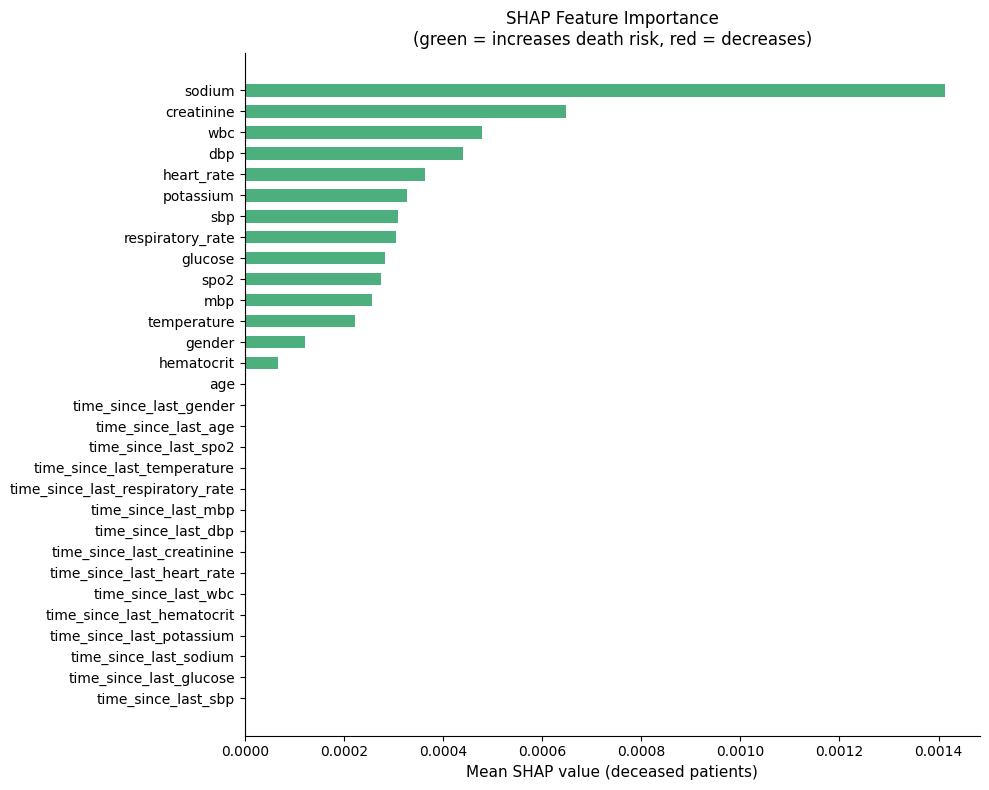

/tmp/ipykernel_2608/2362687845.py:45: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_per_feat,
/tmp/ipykernel_2608/2362687845.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


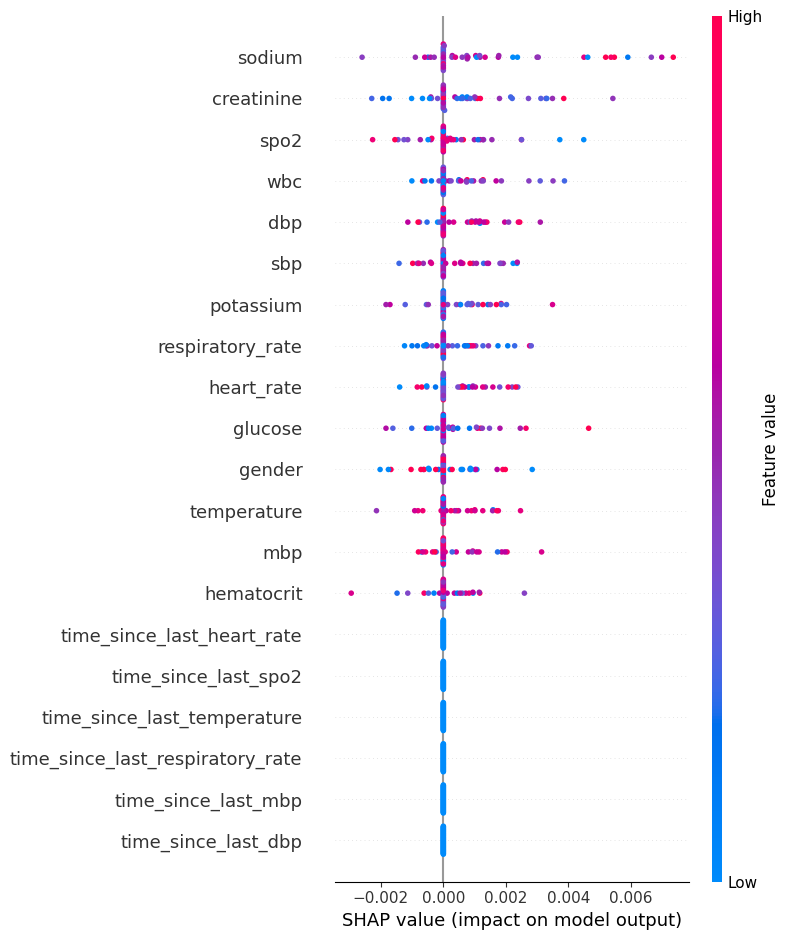


Feature | SHAP | Gradient | Agreement
-------------------------------------------------------
creatinine                         : SHAP +0.00065 | Grad +0.00065 | ✅
glucose                            : SHAP +0.00028 | Grad +0.00028 | ✅
sodium                             : SHAP +0.00141 | Grad +0.00141 | ✅
potassium                          : SHAP +0.00033 | Grad +0.00033 | ✅
hematocrit                         : SHAP +0.00007 | Grad +0.00007 | ✅
wbc                                : SHAP +0.00048 | Grad +0.00048 | ✅
heart_rate                         : SHAP +0.00036 | Grad +0.00036 | ✅
sbp                                : SHAP +0.00031 | Grad +0.00031 | ✅
dbp                                : SHAP +0.00044 | Grad +0.00044 | ✅
mbp                                : SHAP +0.00026 | Grad +0.00026 | ✅
respiratory_rate                   : SHAP +0.00031 | Grad +0.00031 | ✅
temperature                        : SHAP +0.00022 | Grad +0.00022 | ✅
spo2                               : SHAP +0.00028 | 

In [15]:
shap_reshaped   = shap_values.reshape(len(explain_idx), T, F)  # (N, T, F)
shap_per_feat   = shap_reshaped.mean(axis=1)                    # (N, F)
mean_shap       = shap_per_feat.mean(axis=0)                    # (F,)
mean_abs_shap   = np.abs(shap_per_feat).mean(axis=0)            # (F,)

# ---- importance table ----
importance_df = pd.DataFrame({
    'Feature':    feature_names,
    'Mean SHAP':  mean_shap,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

avg_importance = {feat: float(shap_per_feat[:, i].mean()) 
                  for i, feat in enumerate(feature_names)}

# sort
sorted_features = sorted(avg_importance.items(), key=lambda x: x[1], reverse=True)
top_features    = [f for f, _ in sorted_features[:5]]
bottom_features = [f for f, _ in sorted_features[-2:]]

print("Top features:", top_features)
print("Bottom features:", bottom_features)
print("\n" + "="*60)
print("SHAP FEATURE IMPORTANCE (deceased patients)")
print("="*60)
print(importance_df.to_string(index=False))

# ---- bar plot ----
sorted_df = importance_df.sort_values('Mean SHAP')
colors    = ['#e05c5c' if v < 0 else '#4caf7d' for v in sorted_df['Mean SHAP']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(sorted_df['Feature'], sorted_df['Mean SHAP'], color=colors, edgecolor='none', height=0.6)
ax.axvline(x=0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Mean SHAP value (deceased patients)', fontsize=11)
ax.set_title('SHAP Feature Importance\n(green = increases death risk, red = decreases)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
# plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- summary plot ----
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_per_feat, 
                  X_test[explain_idx].reshape(len(explain_idx), T, F).mean(axis=1),
                  feature_names=feature_names, show=False)
plt.tight_layout()
# plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- comparison with gradient importance ----
print("\nFeature | SHAP | Gradient | Agreement")
print("-" * 55)
for feat in feature_names:
    idx      = feature_names.index(feat)
    shap_val = mean_shap[idx]
    grad_val = avg_importance.get(feat, 0)
    agree    = '✅' if np.sign(shap_val) == np.sign(grad_val) else '❌'
    print(f"{feat:35s}: SHAP {shap_val:+.5f} | Grad {grad_val:+.5f} | {agree}")